# Density Based Clustering

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

## Imports

In [78]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [79]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")
artists_df = pd.read_csv("../datasets/artists_cleaned.csv")

## Features Selection

In [80]:
selected_features = [
    # linguistic / lyrics
    # 'n_tokens',
    # 'swear_IT',
    # 'lexical_density',

    # audio features
    # 'bpm',
    'centroid',
    # 'loudness',
    # 'spectral_complexity',
    # 'flux',
    # 'rolloff',

    # popularity
    'popularity',
    # 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    'has_collaboration',
    'aggressiveness',
    # 'song_age',
    # 'duration_sec'
]

In [81]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [82]:
# Check for NaN values
print(X.isna().sum())

centroid             0
popularity           0
has_collaboration    0
aggressiveness       0
dtype: int64


**log1p transformation**: applying log to numeric skewed features

In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for clustering
numeric_features = X.columns.tolist()  # X is our selected features for clustering

# Step 0: Filter out binary and one-hot encoded features (only keep features with >2 unique values)
continuous_features = [col for col in numeric_features if X[col].nunique() > 2]

# Step 1: Compute skewness
skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n", skewness)

# Step 2: Plot distribution of highly skewed features (optional)
high_skew = skewness[skewness > 2].index  # threshold for positive skew
# for col in high_skew:
#     plt.figure()
#     sns.histplot(X[col], kde=True)
#     plt.title(f'Distribution of {col} (skew={skewness[col]:.2f})')
#     plt.show()

# Step 3: Apply log1p transformation to highly skewed continuous features
for col in high_skew:
    # Only apply if all values are >= 0 (log1p cannot handle negative values)
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])
    else:
        print(f"Skipping {col} because it has negative values.")

# Step 4: Verify the new skewness
new_skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness after log1p transformation:\n", new_skewness)

Skewness of continuous features:
 popularity        0.260412
centroid          0.181541
aggressiveness   -0.053941
dtype: float64
Skewness after log1p transformation:
 popularity        0.260412
centroid          0.181541
aggressiveness   -0.053941
dtype: float64


**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [84]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [85]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

In [86]:
X_scaled = X_minmax

## DBScan

### Study of Clustering Parameters

In DBSCAN, we have to choose two parameters:

* **eps:** The maximum distance between two samples for one to be considered as in the neighborhood of the other.

* **min_samples:** The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.

In [87]:
from scipy.spatial.distance import pdist, squareform
import tqdm


def calc_k_nn_dist_graph(X, ub=0., lb=0.):
    k_list = [3, 5, 9, 15]

    dist = pdist(X, 'euclidean')
    dist = squareform(dist)

    for k in k_list:
        kth_distances = []
        for d in dist:
            index_kth_distance = np.argsort(d)[k]
            kth_distances.append(d[index_kth_distance])

        plt.figure(figsize=(8, 6))
        plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
        plt.ylabel('dist from %sth neighbor' % k, fontsize=18)
        plt.xlabel('sorted distances', fontsize=18)
        plt.tick_params(axis='both', which='major', labelsize=12)
        plt.grid()
        plt.axhline(ub)
        plt.axhline(lb)
        plt.title('Graph of distance from %sth nearest neighbor' % k)
        plt.show()

In [88]:
# values of min_samples to try
min_samples = range(3, 25, 3)

In [89]:
# calc_k_nn_dist_graph(X_scaled, 0.01, 0.1)

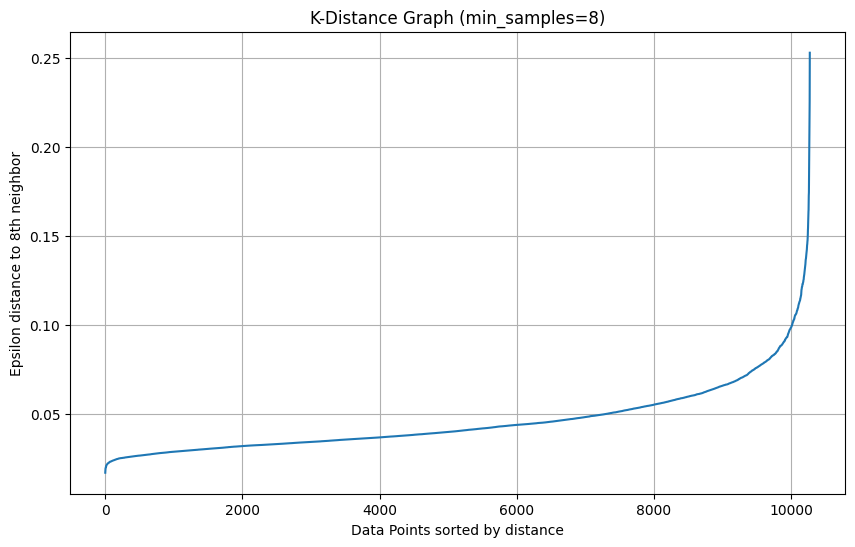

In [90]:
# 1. Select min_samples
min_samples = 2 * len(selected_features)  # Rule of thumb: 2 * len(features)

# 2. Calculate distance to the kth nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 3. Sort distances (we only care about the distance to the min_samples-th neighbor)
distances = np.sort(distances[:, min_samples-1], axis=0)

# 4. Plot the k-distance Graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title(f'K-Distance Graph (min_samples={min_samples})')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'Epsilon distance to {min_samples}th neighbor')
plt.grid(True)
plt.show()

In [95]:
# --- PARAMETERS ---
# REPLACE 0.6 with the value you found in the plot above!
best_eps = 0.8
best_min_samples = min_samples

# --- RUN DBSCAN ---
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)

# Add labels to dataframe
X['dbscan_cluster'] = labels

# Count clusters
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f'DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
print(f'Number of labels: {len(set(labels))}')
print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')
print(f'Noise ratio: {n_noise_ / len(labels):.2%}')

# Print count of each label
print("\nCounts per label:")
print(pd.Series(labels).value_counts().sort_index())


DBSCAN (eps=0.8, min_samples=8)
Number of labels: 2
Estimated number of clusters: 2
Estimated number of noise points: 0
Noise ratio: 0.00%

Counts per label:
0    3362
1    6910
Name: count, dtype: int64


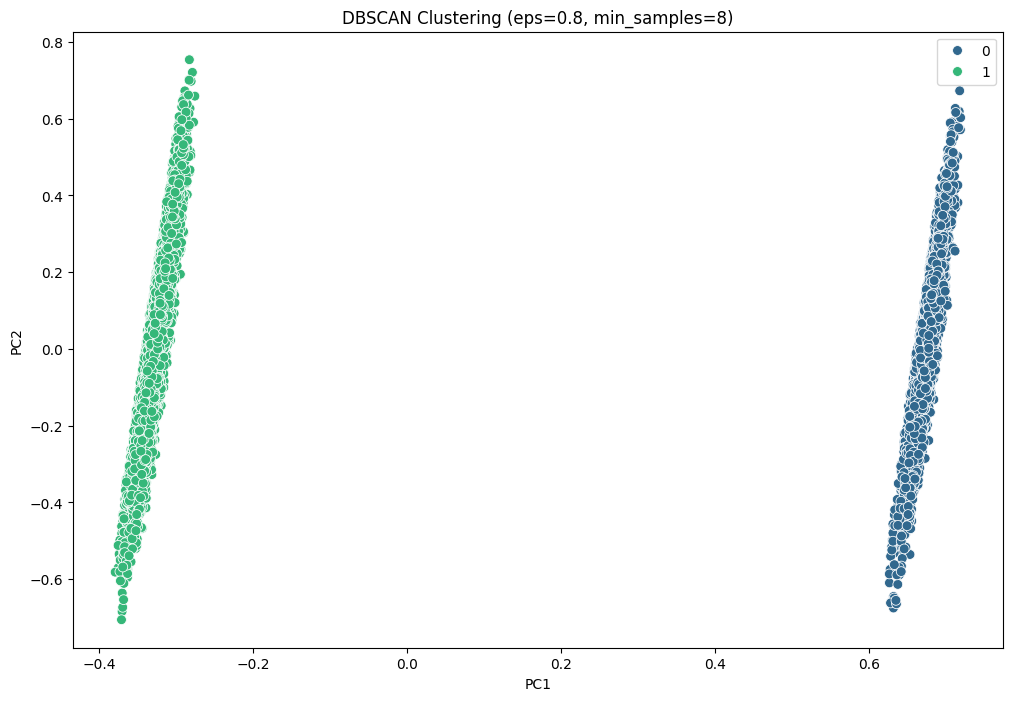

In [96]:
# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a temporary dataframe for plotting
plot_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
plot_df['Cluster'] = labels

plt.figure(figsize=(12, 8))
# Plot Noise (Cluster -1) in Grey/Black and smaller
sns.scatterplot(
    x='PC1', y='PC2', 
    data=plot_df[plot_df['Cluster'] == -1], 
    color='lightgrey', label='Noise', alpha=0.5, s=20
)
# Plot Clusters in Color
sns.scatterplot(
    x='PC1', y='PC2', 
    data=plot_df[plot_df['Cluster'] != -1], 
    hue='Cluster', palette='viridis', s=50
)
plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})')
plt.legend()
plt.show()

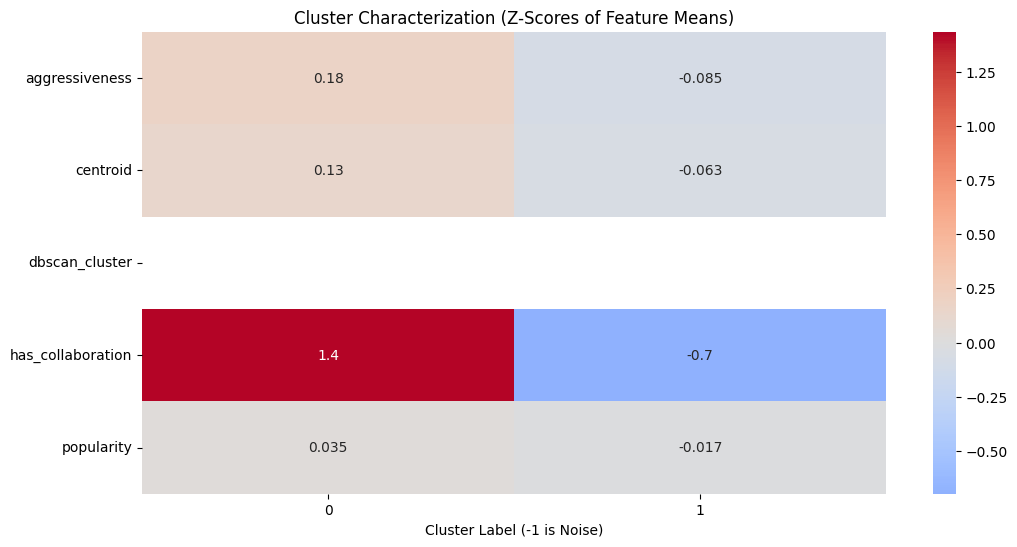

In [93]:
# Group by cluster and calculate mean of features
cluster_profile = X.groupby('dbscan_cluster').mean()

# We usually check how they deviate from the global mean (Z-scores for interpretation)
global_mean = X.mean()
global_std = X.std()

# Calculate Z-score of the cluster centers relative to the whole dataset
cluster_profile_z = (cluster_profile - global_mean) / global_std

# Plot Heatmap of Feature Importance
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile_z.T, cmap='coolwarm', center=0, annot=True)
plt.title('Cluster Characterization (Z-Scores of Feature Means)')
plt.xlabel('Cluster Label (-1 is Noise)')
plt.show()